# Prédiction de l'age 

Pour réaliser les prédiction nous n'utiliseront pas le sex car  à prioerer le sex n'influe pas sur l'age

In [151]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor

In [152]:
def get_linear_regression_coefficients(lr, feature_names):
    coef = pd.DataFrame(lr.coef_.ravel(), index=feature_names, columns=["coef"])
    coef.loc["intercept"] = lr.intercept_
    return coef

def evaluate_classification_model(y_true, y_pred, model):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=model.classes_,
        display_labels=model.classes_,
    )

In [153]:
columns = ["Sex", "Length", "Diam", "Height", "Whole", "Shucked", "Viscera", "Shell", "Rings"]
abalone = pd.read_csv('data.csv', names=columns)
abalone['Sex'] = abalone['Sex'].astype('category')

In [154]:
random_state = 42
train_set, test_set = train_test_split(abalone[columns[1:]], test_size=0.2, random_state=random_state)
X_train = train_set.drop('Rings', axis=1)
y_train = train_set['Rings']
X_test = test_set.drop('Rings', axis=1)
y_test = test_set['Rings']

In [155]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mean_squared_error(y_test, y_pred)

5.055541144299385

In [156]:
get_linear_regression_coefficients(lr, X_train.columns)

,coef
Length,-1.521104
Diam,13.480159
Height,11.399510
Whole,9.154485
Shucked,-20.580206
Viscera,-8.852471
Shell,8.641625
intercept,2.986805


In [157]:
lr_positive_coef = LinearRegression(positive=True)
lr_positive_coef.fit(X_train, y_train)
y_pred_positive_coef = lr_positive_coef.predict(X_test)
mean_squared_error(y_test, y_pred_positive_coef)  

6.404765673364745

In [158]:
get_linear_regression_coefficients(lr_positive_coef, X_train.columns)

,coef
Length,0.000000
Diam,0.000000
Height,9.399188
Whole,0.000000
Shucked,0.000000
Viscera,0.000000
Shell,12.055899
intercept,5.741134


In [159]:
lr_ridge = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1])
lr_ridge.fit(X_train, y_train)
y_pred_ridge = lr_ridge.predict(X_test)
mean_squared_error(y_test, y_pred_ridge)

5.101640995532038

In [160]:
get_linear_regression_coefficients(lr_ridge, X_train.columns)

,coef
Length,2.686723
Diam,7.724535
Height,8.220489
Whole,6.834536
Shucked,-17.644608
Viscera,-5.236480
Shell,10.803902
intercept,3.270418


In [161]:
lr_lasso = LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1])
lr_lasso.fit(X_train, y_train)
y_pred_lasso = lr_lasso.predict(X_test)
mean_squared_error(y_test, y_pred_lasso)

5.070760318502743

In [162]:
get_linear_regression_coefficients(lr_lasso, X_train.columns)

,coef
Length,0.000000
Diam,11.302173
Height,10.025632
Whole,8.276596
Shucked,-19.736176
Viscera,-6.902252
Shell,9.530656
intercept,3.129395


In [163]:
rf = RandomForestRegressor(n_estimators=100, random_state=random_state)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mean_squared_error(y_test, y_pred_rf)

5.1715794258373196

In [164]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=random_state)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
mean_squared_error(y_test, y_pred_gb)

5.227944746851982

# Prédiction de Sex

Pour réaliser les prédiction nous n'utiliseront pas l'age car à priori l'age n'influe pas sur le sex

In [118]:
abalone_F_M = abalone[abalone['Sex'].isin(['F', 'M'])]
train_set, test_set = train_test_split(abalone_F_M, test_size=0.2, random_state=random_state)
X_train = train_set.drop(['Sex','Rings'], axis=1)
y_train = train_set['Sex']
X_test = test_set.drop(['Sex','Rings'], axis=1)
y_test = test_set['Sex']

Accuracy: 0.5379


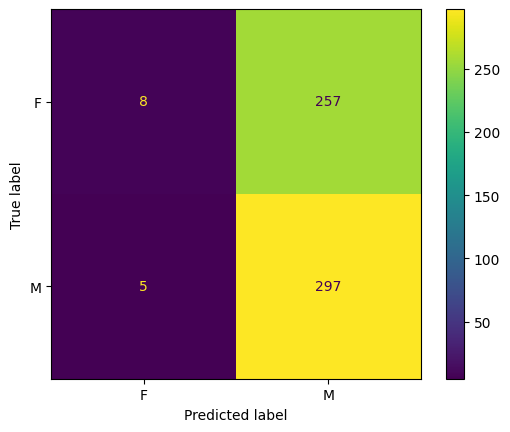

In [144]:
logr = LogisticRegression(C=0.1, l1_ratio=0, solver='liblinear', random_state=random_state, max_iter=1000)
logr.fit(X_train, y_train)
y_pred_logr = logr.predict(X_test)
evaluate_classification_model(y_test, y_pred_logr, logr)

In [121]:
get_linear_regression_coefficients(logr, X_train.columns)

,coef
Length,-0.196115
Diam,-0.184972
Height,-0.114842
Whole,-0.174747
Shucked,0.458271
Viscera,-0.202876
Shell,-0.252526
intercept,0.462847


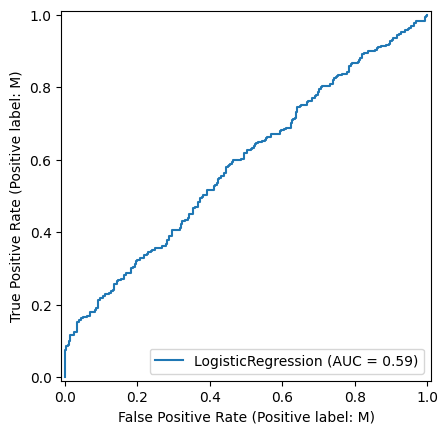

In [129]:
RocCurveDisplay.from_estimator(logr, X_test, y_test)

Accuracy: 0.5556


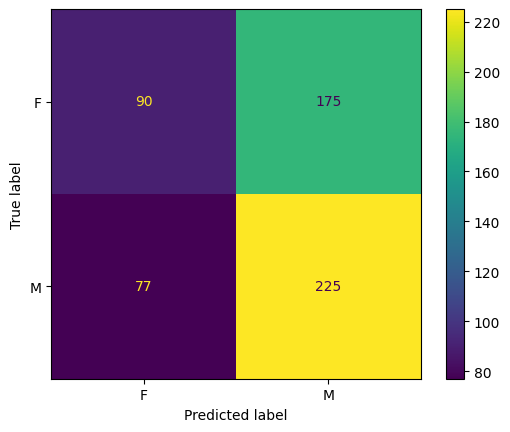

In [145]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
evaluate_classification_model(y_test, y_pred_lda, lda)

Accuracy: 0.5644


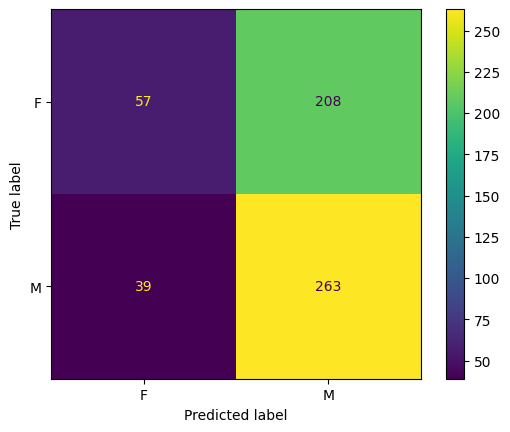

In [146]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
evaluate_classification_model(y_test, y_pred_qda, qda)

Accuracy: 0.5397


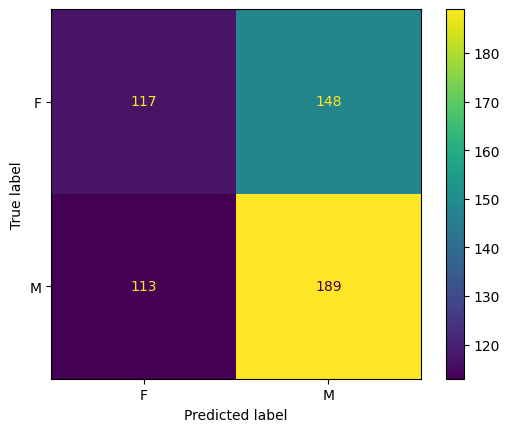

In [147]:
rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_classification_model(y_test, y_pred_rf, rf)

Accuracy: 0.5379


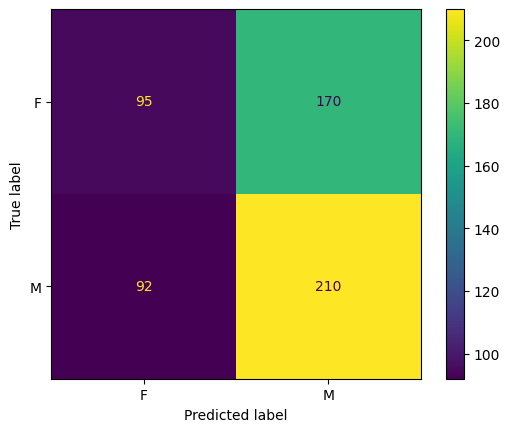

In [148]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=random_state)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
evaluate_classification_model(y_test, y_pred_gb, gb)

Accuracy: 0.5467


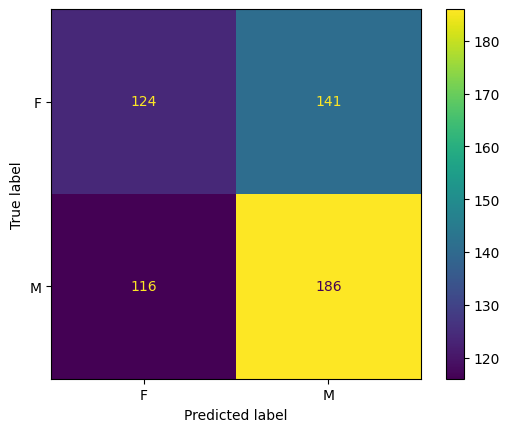

In [149]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_classification_model(y_test, y_pred_knn, knn)

Nous n’avons pas réussit à établir de règle de classement satisfesante. On peut supposer que l’on ne peux
pas différencier le sex des coquillage en fonction de leur attribut physique et qu’il faudrait d’autre type de
données pour les classer.